In [2]:
import pandas as pd
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, opinion_lexicon
import string
from nltk.stem import PorterStemmer
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
import numpy as np
import networkx as nx
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/Users/irisli/PSTAT_134/final_project/netflix_reviews.csv")


In [3]:
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='str')

In [4]:
df = df.drop(columns = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion'])
df.columns

Index(['content', 'score'], dtype='str')

In [5]:
# making a sample of 10000 entries from the dataset
sample, _ = train_test_split(df, train_size = 10000, stratify = df['score'], random_state = 42)
sample.reset_index(drop = True, inplace = True)
sample['score'].value_counts()

score
1    3930
5    3173
4    1084
3     946
2     867
Name: count, dtype: int64

In [6]:
len(sample)

10000

In [7]:
# droping null values, removing punctuation, and converting to lowercase
sample = sample.dropna()
sample['content'] = sample['content'].str.replace(r"[^A-Za-z\s]", "", regex=True).str.lower()

In [8]:
len(sample)

9998

In [9]:
# no more null values
sample.isna().sum()

content    0
score      0
dtype: int64

In [10]:
# making a new column which has a list of all words in that row's content column and then dropping the content column
sample['content_tokenized'] = sample['content'].apply(word_tokenize) 
sample = sample.drop(columns = ['content'])

In [11]:
# defining set of stopwords
stop_words = set(stopwords.words('english'))

# defining function to remove stop words
def remove_stop(review):
    filtered = [word for word in review if word not in stop_words]
    return filtered

In [12]:
# removing stop words from content_tokenized column
sample['content_tokenized'] = sample['content_tokenized'].apply(remove_stop)

In [13]:
# making another column in sample with the words from the cleaned content column as strings
def into_string(content):
    return " ".join(content)

sample['content_string'] = sample['content_tokenized'].apply(into_string)

In [14]:
# swapping order of columns for improved readablility
sample = sample[['content_tokenized', 'content_string', 'score']]

In [15]:
sample.head(10)

,content_tokenized,content_string,score
0,"[used, netflix, years, mainly, low, pricing, g...",used netflix years mainly low pricing good sel...,1
1,"[playing, anything, huawei, p, pro, everytime,...",playing anything huawei p pro everytime video ...,1
2,"[new, update, stupid, dad, lives, different, s...",new update stupid dad lives different state us...,2
3,"[nice, app]",nice app,5
4,"[dont, know, download, movie, become, slowi, n...",dont know download movie become slowi need res...,3
5,"[love, neftlix, love, watch, movies, tv, dead,...",love neftlix love watch movies tv dead fun wat...,5
6,[good],good,5
7,"[lets, take, im, using, x, profile, showing, p...",lets take im using x profile showing profile l...,5
8,"[still, semi, regularly, hands, logo, paying, ...",still semi regularly hands logo paying content...,1
9,"[app, open, oneplus, pro, stuck, netflix, load...",app open oneplus pro stuck netflix loading scr...,1


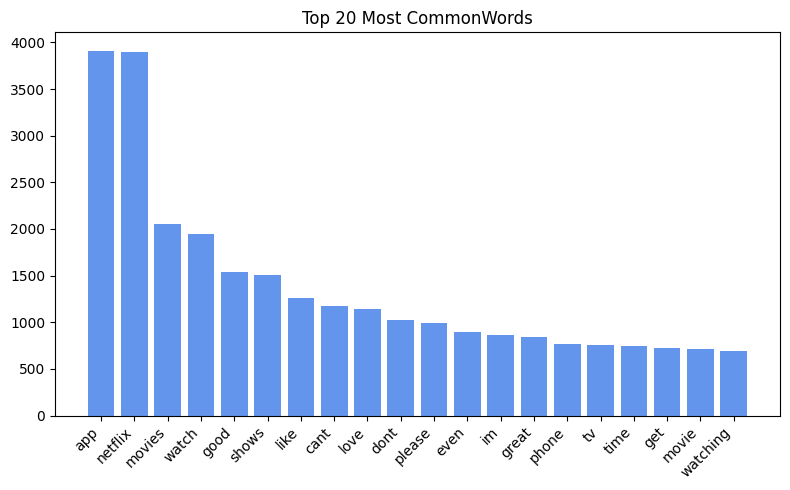

In [16]:
# bar chart for most common words
all_words = [w for tokens in sample['content_tokenized'] for w in tokens]
top_overall = Counter(all_words).most_common(20)

words, counts = zip(*top_overall)
plt.figure(figsize=(8, 5))
plt.bar(words, counts, color='cornflowerblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most CommonWords')
plt.tight_layout()
plt.show()

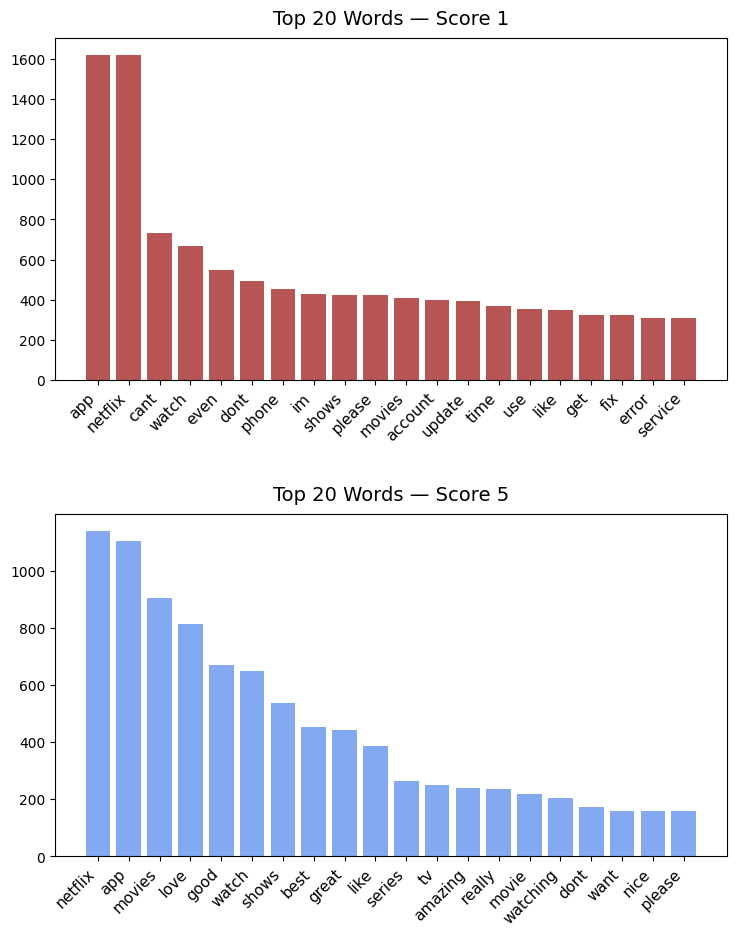

In [24]:
# bar chart for most common words of the highest and lowest scores
score_colors = {1: 'brown', 5: 'cornflowerblue'}

fig, axes = plt.subplots(2, 1, figsize=(8, 10))
for ax, score in zip(axes, [1, 5]):
    words_score = [
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    ]
    top = Counter(words_score).most_common(20)
    w, c = zip(*top)
    ax.bar(w, c, color=score_colors[score], alpha=0.8)
    ax.set_title(f'Top 20 Words — Score {score}', fontsize=14, pad=10)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xticklabels(w, rotation=45, ha='right')
plt.tight_layout(pad=3.0)
plt.show()

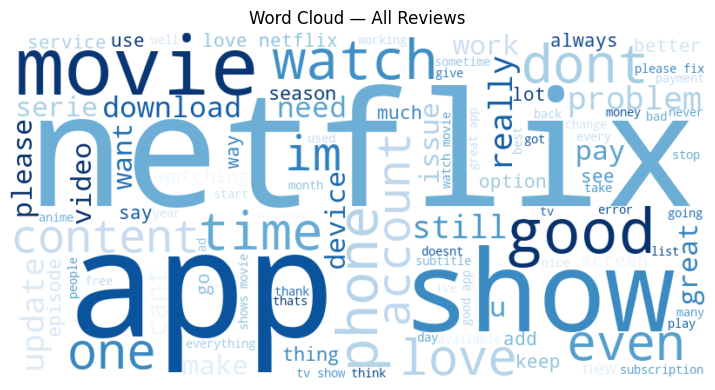

In [18]:
# word cloud for most common-occurring words
text_all = ' '.join(
    w for tokens in sample['content_tokenized']
    for w in tokens
)
wc = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(text_all)

plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Reviews')
plt.tight_layout()
plt.show()

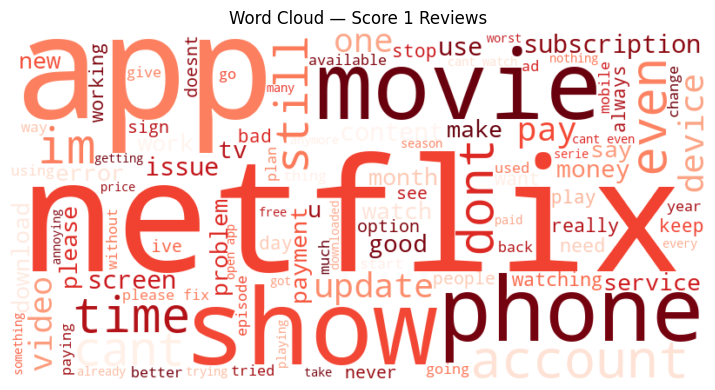

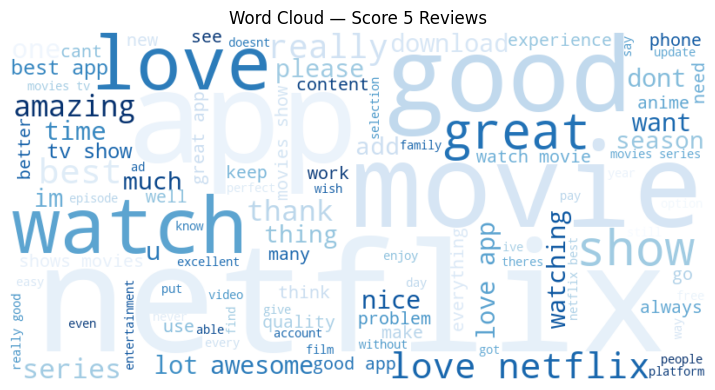

In [25]:
# word cloud for most common words of the highest and lowest scores
cloud_colormaps = {1: 'Reds', 5: 'Blues'}

for score in [1, 5]:
    text = ' '.join(
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    )
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cloud_colormaps[score],
        max_words=100
    ).generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — Score {score} Reviews')
    plt.tight_layout()
    plt.savefig(f'wordcloud_score_{score}.png', dpi=150)
    plt.show()

In [20]:
# Calculate TF-IDF values for all words in the dataset
tfidf_vectorizer = TfidfVectorizer(max_features=None)  # Keep all features
tfidf_matrix = tfidf_vectorizer.fit_transform(sample['content_string'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF values for each word across all documents
tfidf_mean = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Create a DataFrame with words and their mean TF-IDF values
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'mean_tfidf': tfidf_mean
}).sort_values('mean_tfidf', ascending=False)

print(f"Total number of unique words: {len(tfidf_df)}")
print("\nTF-IDF Statistics:")
print(tfidf_df['mean_tfidf'].describe())

Total number of unique words: 11388

TF-IDF Statistics:
count    11388.000000
mean         0.000273
std          0.001232
min          0.000006
25%          0.000029
50%          0.000047
75%          0.000110
max          0.044675
Name: mean_tfidf, dtype: float64


In [21]:
# Top 30 words with largest TF-IDF values
top_30_tfidf = tfidf_df.head(30)
print("=" * 60)
print("TOP 30 WORDS WITH LARGEST TF-IDF VALUES")
print("=" * 60)
print(top_30_tfidf.to_string())
print("\n")

TOP 30 WORDS WITH LARGEST TF-IDF VALUES
           word  mean_tfidf
564         app    0.044675
4147       good    0.040699
6605    netflix    0.039364
6391     movies    0.030826
10956     watch    0.025746
5852       love    0.024435
9012      shows    0.022586
4228      great    0.018816
5680       like    0.018176
1506       cant    0.017419
1059       best    0.015717
7473     please    0.014733
2890       dont    0.014263
10384        tv    0.013054
6382      movie    0.012634
3336       even    0.012592
7351      phone    0.012255
10623    update    0.012208
4772         im    0.011995
6689       nice    0.011907
8843     series    0.011843
10136      time    0.011701
10971  watching    0.011480
10687       use    0.011307
4060        get    0.010832
6658        new    0.010783
8005     really    0.010622
3728        fix    0.010013
10926      want    0.009951
8694     screen    0.009856




In [22]:
# Bottom 30 words with smallest TF-IDF values
bottom_30_tfidf = tfidf_df.tail(30).sort_values('mean_tfidf', ascending=True)
print("=" * 60)
print("BOTTOM 30 WORDS WITH SMALLEST TF-IDF VALUES")
print("=" * 60)
print(bottom_30_tfidf.to_string())
print("\n")

BOTTOM 30 WORDS WITH SMALLEST TF-IDF VALUES
          word  mean_tfidf
8454       rob    0.000006
4635    horroi    0.000006
8452       rng    0.000009
10363       tt    0.000009
8413        ri    0.000009
10332     trng    0.000009
10827  vietsub    0.000009
7865        qu    0.000009
4075        gi    0.000009
6320      mong    0.000009
7874      quan    0.000009
9201        sn    0.000009
7908       qut    0.000009
10371      tui    0.000009
1183        bn    0.000009
4595       hon    0.000009
10152      tin    0.000009
1726      chnh    0.000009
11294      xut    0.000009
10177       tm    0.000009
2302       cuc    0.000009
5750        lm    0.000009
6687       nht    0.000009
5385       khi    0.000009
2428       dch    0.000009
6681       ngy    0.000009
5752        ln    0.000009
4807   importa    0.000011
10186     todo    0.000011
10133    tilda    0.000011




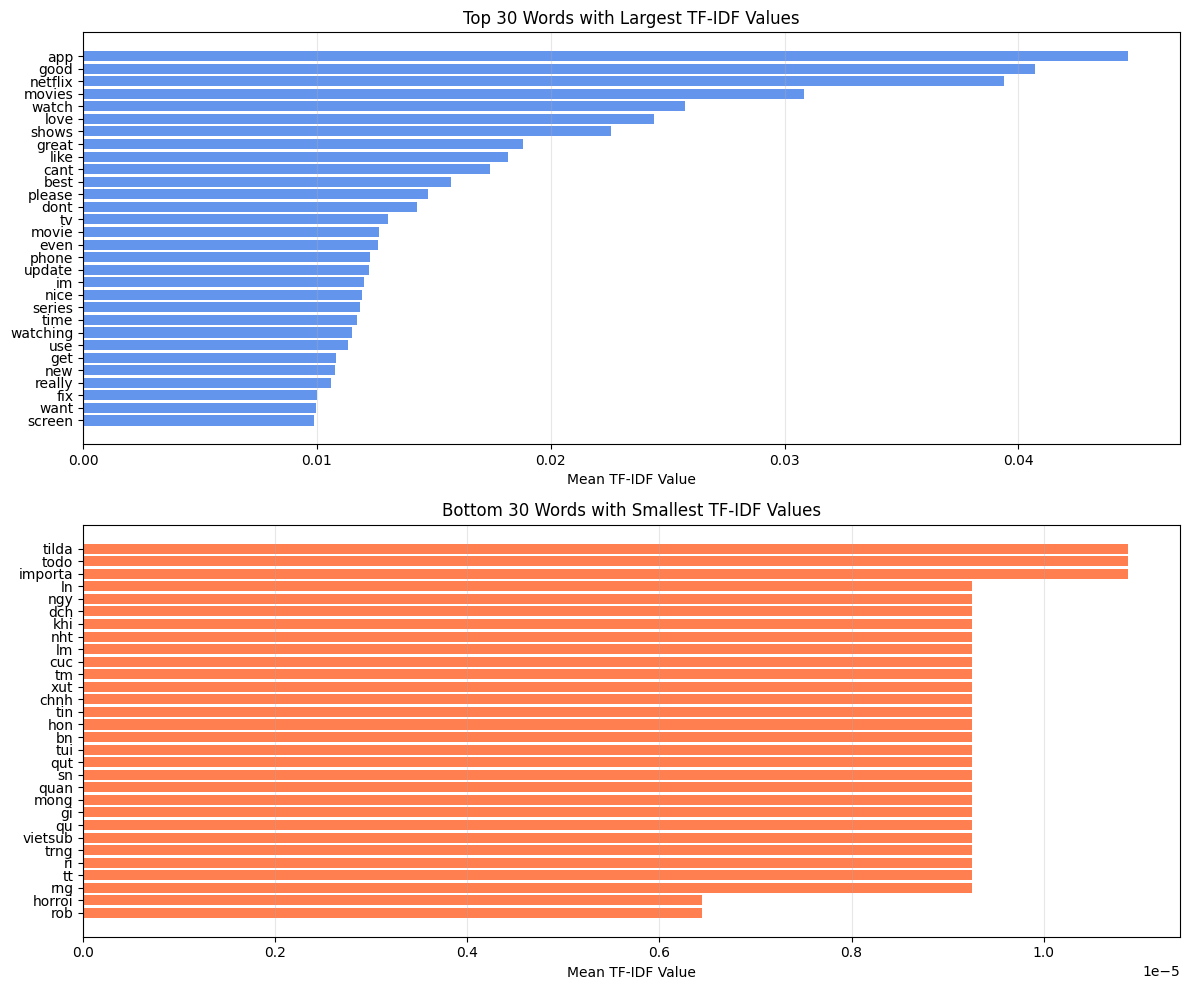

In [23]:
# Visualization of top and bottom 30 TF-IDF values
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 30
top_30_sorted = top_30_tfidf.sort_values('mean_tfidf', ascending=True)
axes[0].barh(top_30_sorted['word'], top_30_sorted['mean_tfidf'], color='cornflowerblue')
axes[0].set_xlabel('Mean TF-IDF Value')
axes[0].set_title('Top 30 Words with Largest TF-IDF Values')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 30
axes[1].barh(bottom_30_tfidf['word'], bottom_30_tfidf['mean_tfidf'], color='coral')
axes[1].set_xlabel('Mean TF-IDF Value')
axes[1].set_title('Bottom 30 Words with Smallest TF-IDF Values')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()